# Descripcipción del proyecto

Film Junky Union, una nueva comunidad vanguardista para los aficionados de las películas clásicas, está desarrollando un sistema para filtrar y categorizar reseñas de películas. Tu objetivo es entrenar un modelo para detectar las críticas negativas de forma automática. Para lograrlo, utilizarás un conjunto de datos de reseñas de películas de IMDB con leyendas de polaridad para construir un modelo para clasificar las reseñas positivas y negativas. Este deberá alcanzar un valor F1 de al menos 0.85.

## Inicialización

In [21]:
import math

import numpy as np
import pandas as pd

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
sns.set_theme()


from tqdm.auto import tqdm

In [22]:
#%matplotlib inline
#%config InlineBackend.figure_format = 'png'
# la siguiente línea proporciona gráficos de mejor calidad en pantallas HiDPI
# %config InlineBackend.figure_format = 'retina'

#plt.style.use('seaborn')

In [23]:
# esto es para usar progress_apply, puedes leer más en https://pypi.org/project/tqdm/#pandas-integration
tqdm.pandas()

## Cargar datos

In [24]:
url = 'https://practicum-content.s3.us-west-1.amazonaws.com/datasets/imdb_reviews.tsv'
df_reviews = pd.read_csv(url, sep='\t')

In [25]:
#Primeros datos
df_reviews.head()

,tconst,title_type,primary_title,original_title,start_year,end_year,runtime_minutes,is_adult,genres,average_rating,votes,review,rating,sp,pos,ds_part,idx
0,tt0068152,movie,$,$,1971,\N,121,0,"Comedy,Crime,Drama",6.3,2218.0,The pakage implies that Warren Beatty and Gold...,1,neg,0,train,8335
1,tt0068152,movie,$,$,1971,\N,121,0,"Comedy,Crime,Drama",6.3,2218.0,How the hell did they get this made?! Presenti...,1,neg,0,train,8336
2,tt0313150,short,'15','15',2002,\N,25,0,"Comedy,Drama,Short",6.3,184.0,There is no real story the film seems more lik...,3,neg,0,test,2489
3,tt0313150,short,'15','15',2002,\N,25,0,"Comedy,Drama,Short",6.3,184.0,Um .... a serious film about troubled teens in...,7,pos,1,test,9280
4,tt0313150,short,'15','15',2002,\N,25,0,"Comedy,Drama,Short",6.3,184.0,I'm totally agree with GarryJohal from Singapo...,9,pos,1,test,9281


In [26]:
#Información general
df_reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47331 entries, 0 to 47330
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   tconst           47331 non-null  object 
 1   title_type       47331 non-null  object 
 2   primary_title    47331 non-null  object 
 3   original_title   47331 non-null  object 
 4   start_year       47331 non-null  int64  
 5   end_year         47331 non-null  object 
 6   runtime_minutes  47331 non-null  object 
 7   is_adult         47331 non-null  int64  
 8   genres           47331 non-null  object 
 9   average_rating   47329 non-null  float64
 10  votes            47329 non-null  float64
 11  review           47331 non-null  object 
 12  rating           47331 non-null  int64  
 13  sp               47331 non-null  object 
 14  pos              47331 non-null  int64  
 15  ds_part          47331 non-null  object 
 16  idx              47331 non-null  int64  
dtypes: float64(2

In [27]:
#Valores nulos por columna
print(df_reviews.isnull().sum())

tconst             0
title_type         0
primary_title      0
original_title     0
start_year         0
end_year           0
runtime_minutes    0
is_adult           0
genres             0
average_rating     2
votes              2
review             0
rating             0
sp                 0
pos                0
ds_part            0
idx                0
dtype: int64


In [28]:
# Eliminar filas con valores nulos
df_reviews = df_reviews.dropna().reset_index(drop=True)

Como son pocos los datos ausentes, se procede a eliminar dichas filas.

pos
0    23715
1    23614
Name: count, dtype: int64


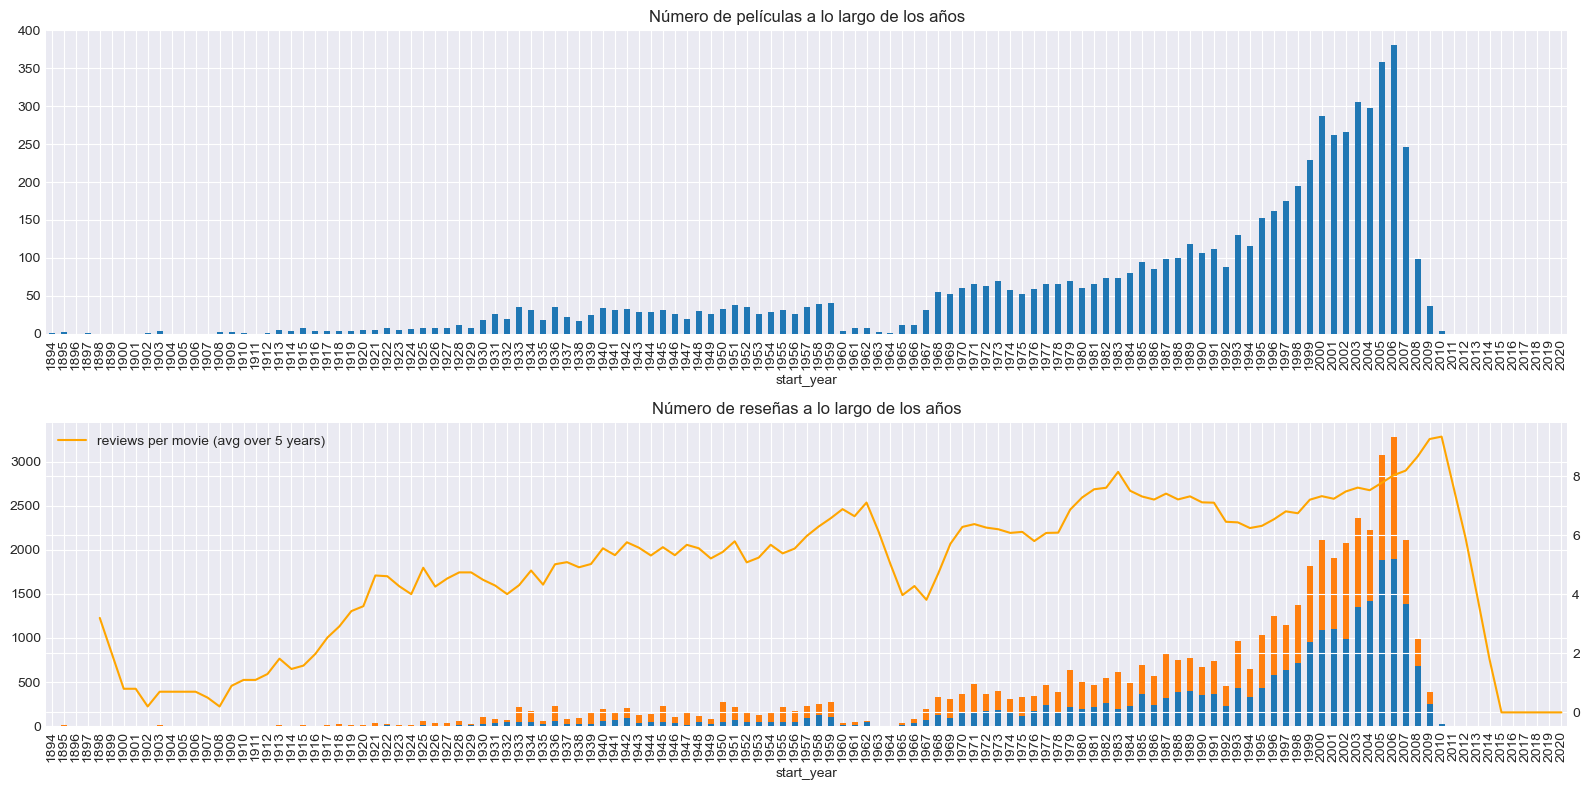

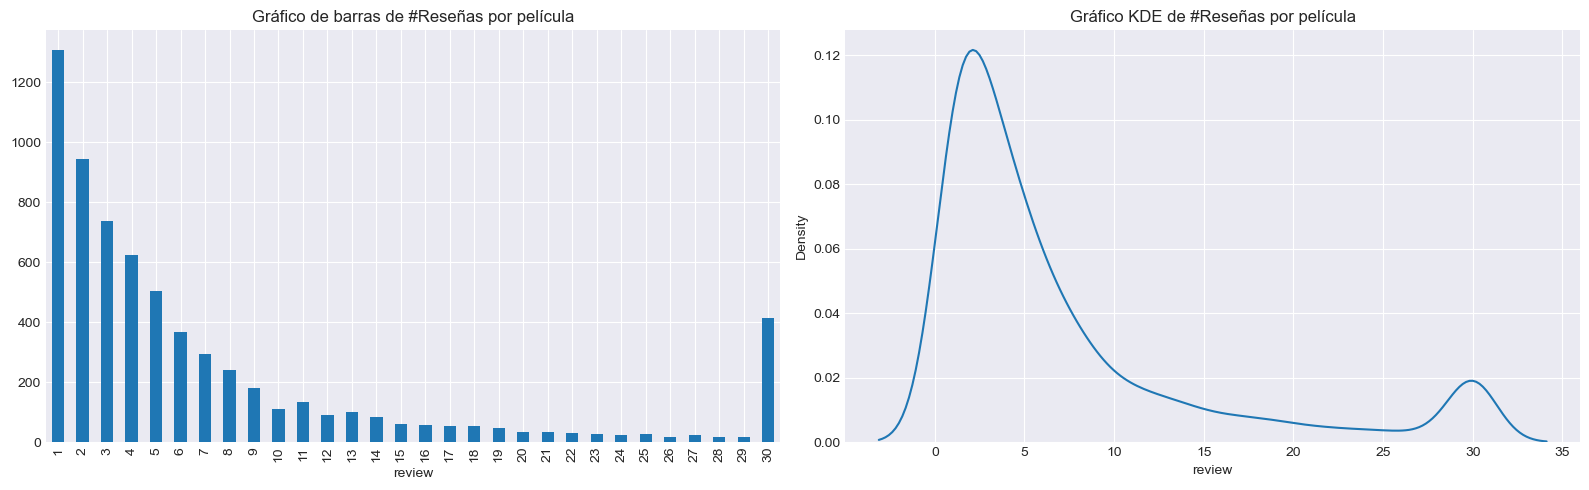

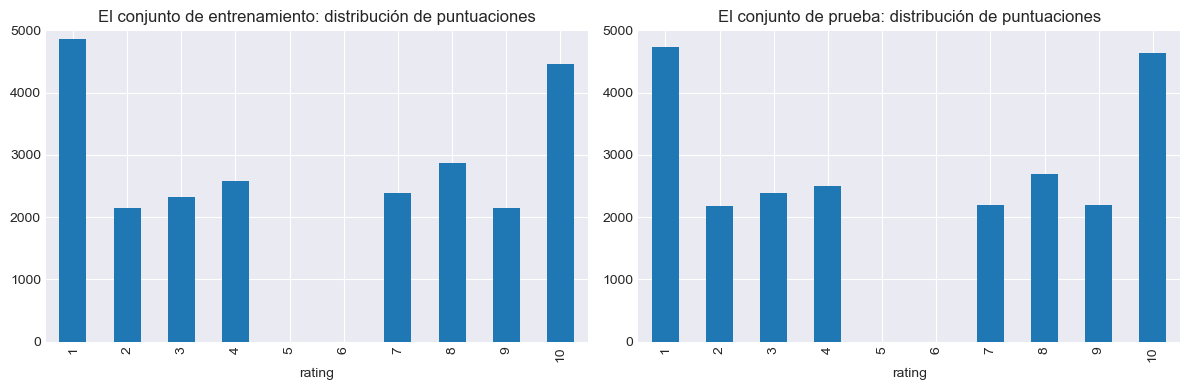

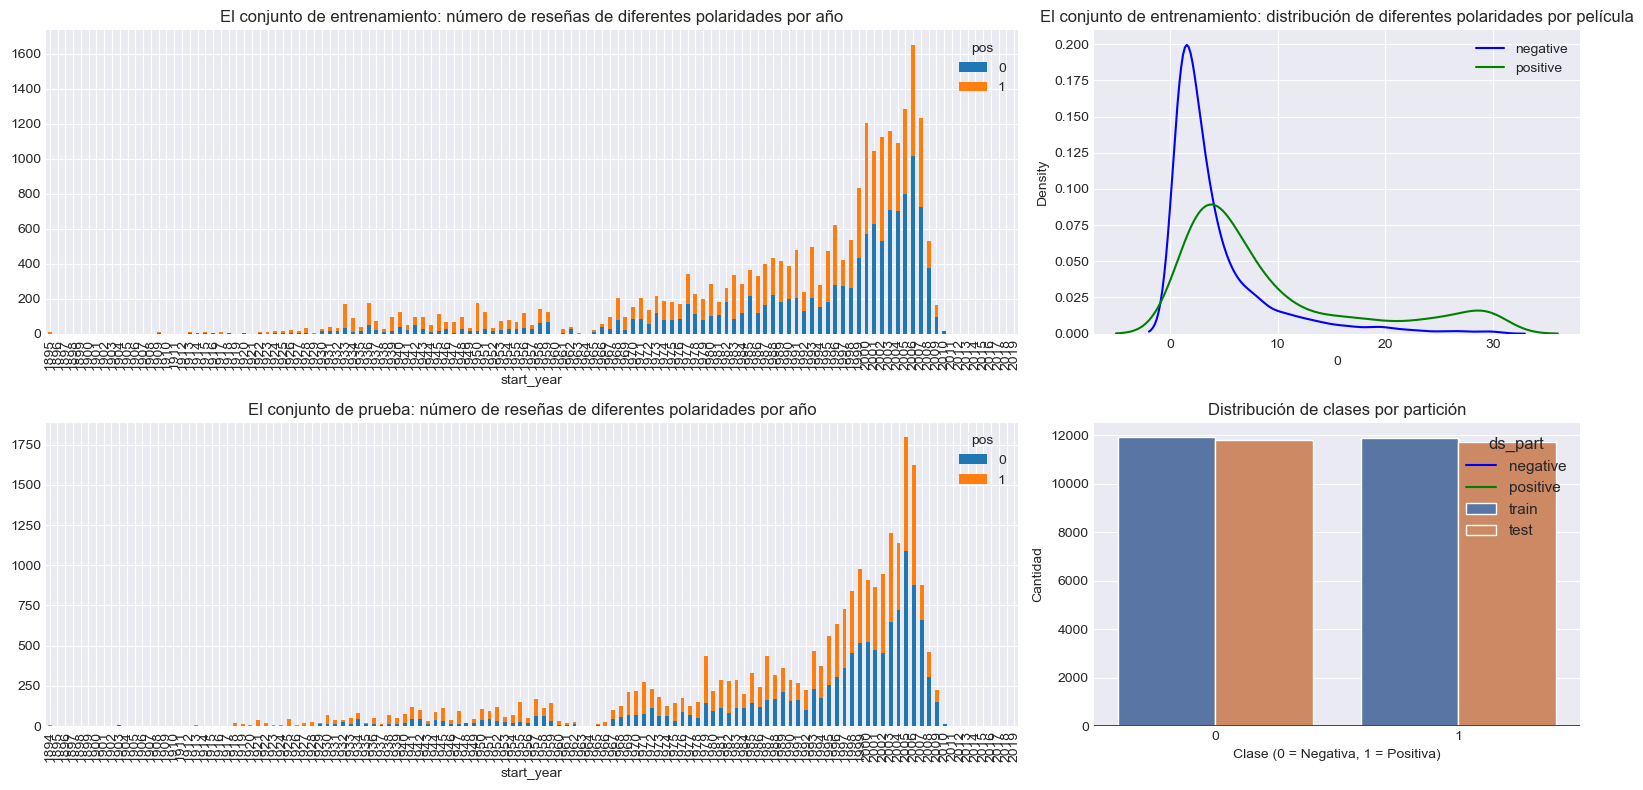

In [29]:
#Distribución de clases
print(df_reviews['pos'].value_counts())

# Visualización de la distribución

sns.countplot(data=df_reviews, x='pos', hue='ds_part')
plt.title('Distribución de clases por partición')
plt.xlabel('Clase (0 = Negativa, 1 = Positiva)')
plt.ylabel('Cantidad')
plt.show()



Se observa que las clases se encuentran bien balanceadas, lo cual es ideal para entrenar modelos sin aplicar técnicas de balenceo.

## EDA

Veamos el número de películas y reseñas a lo largo de los años.

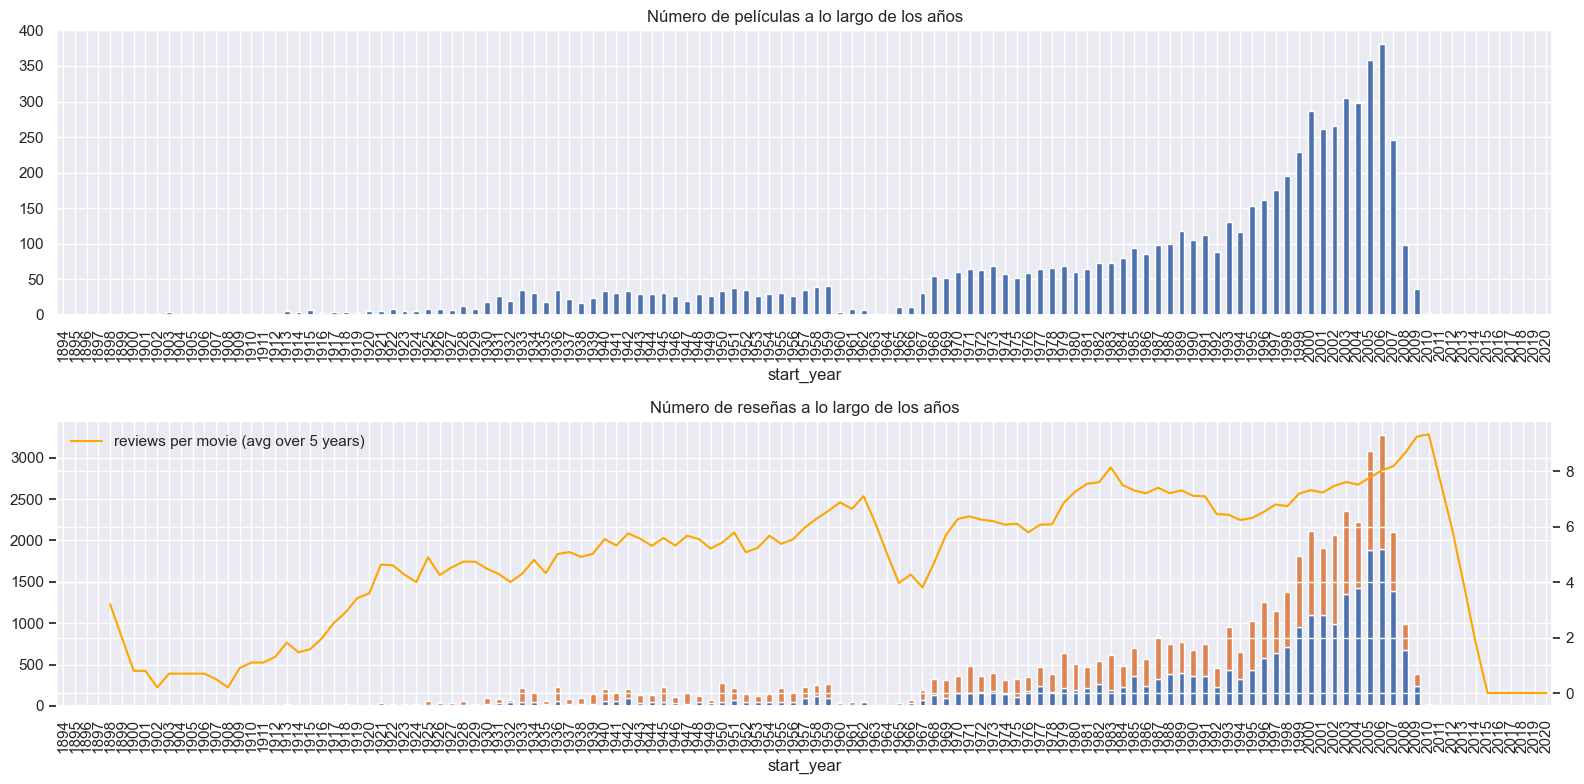

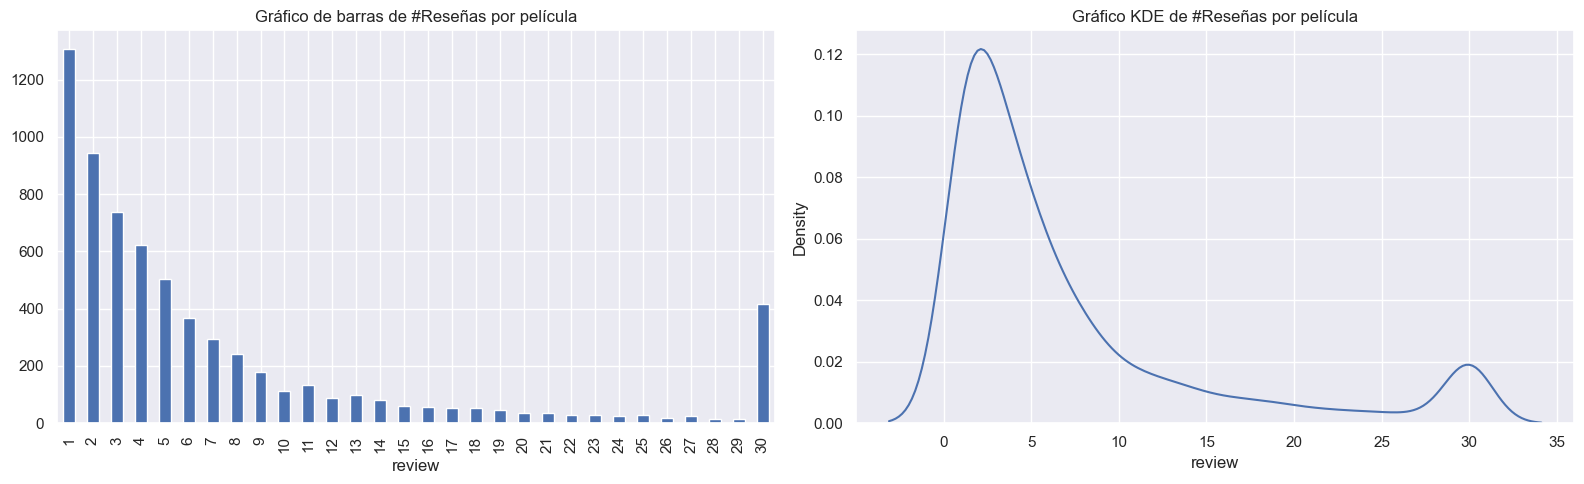

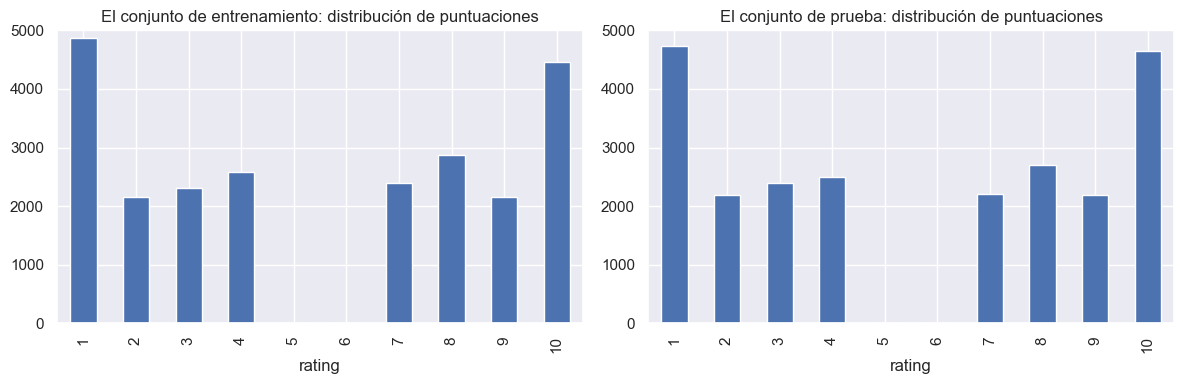

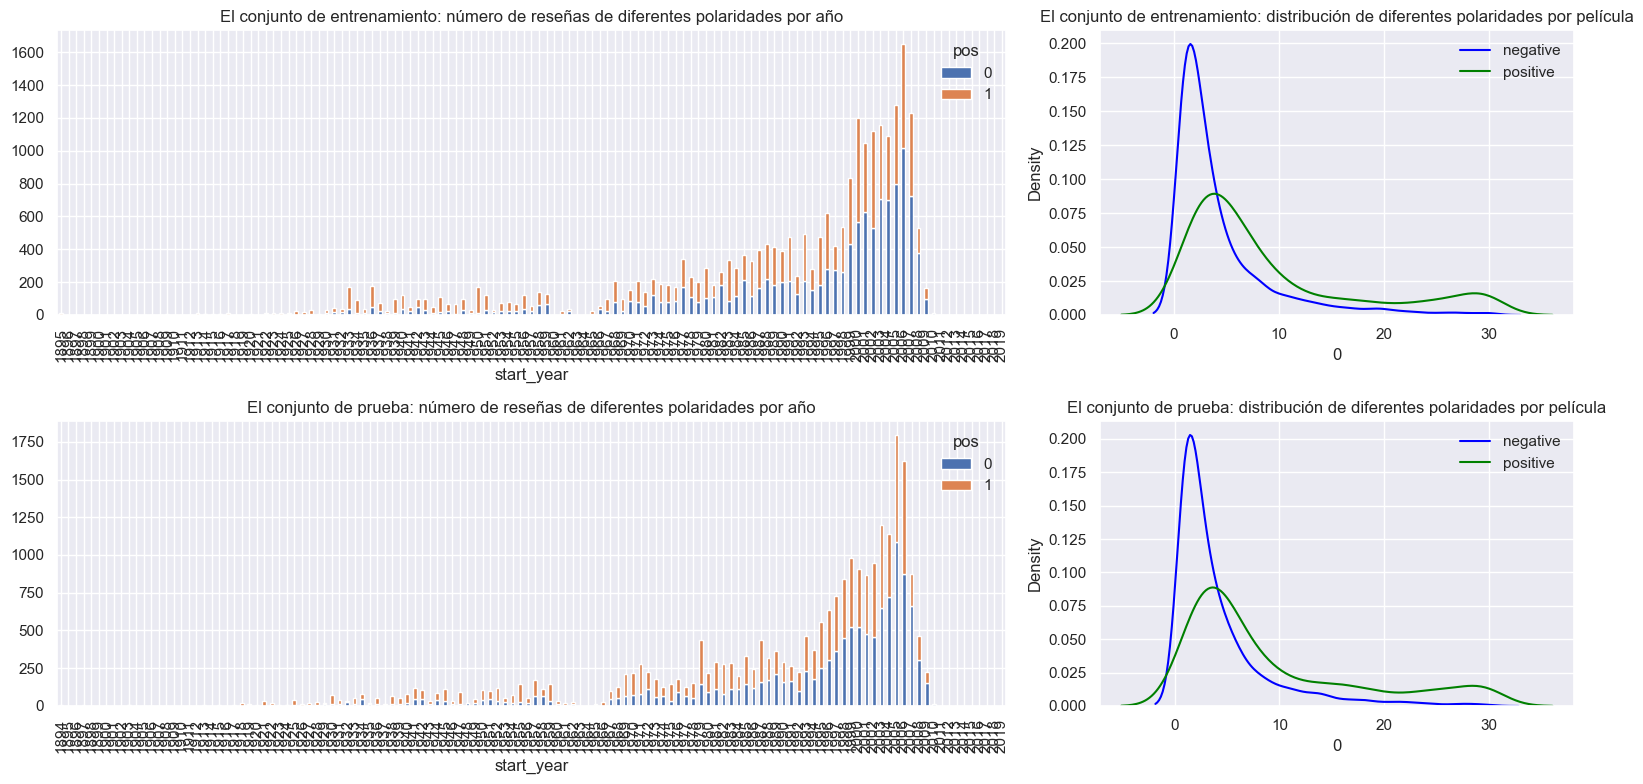

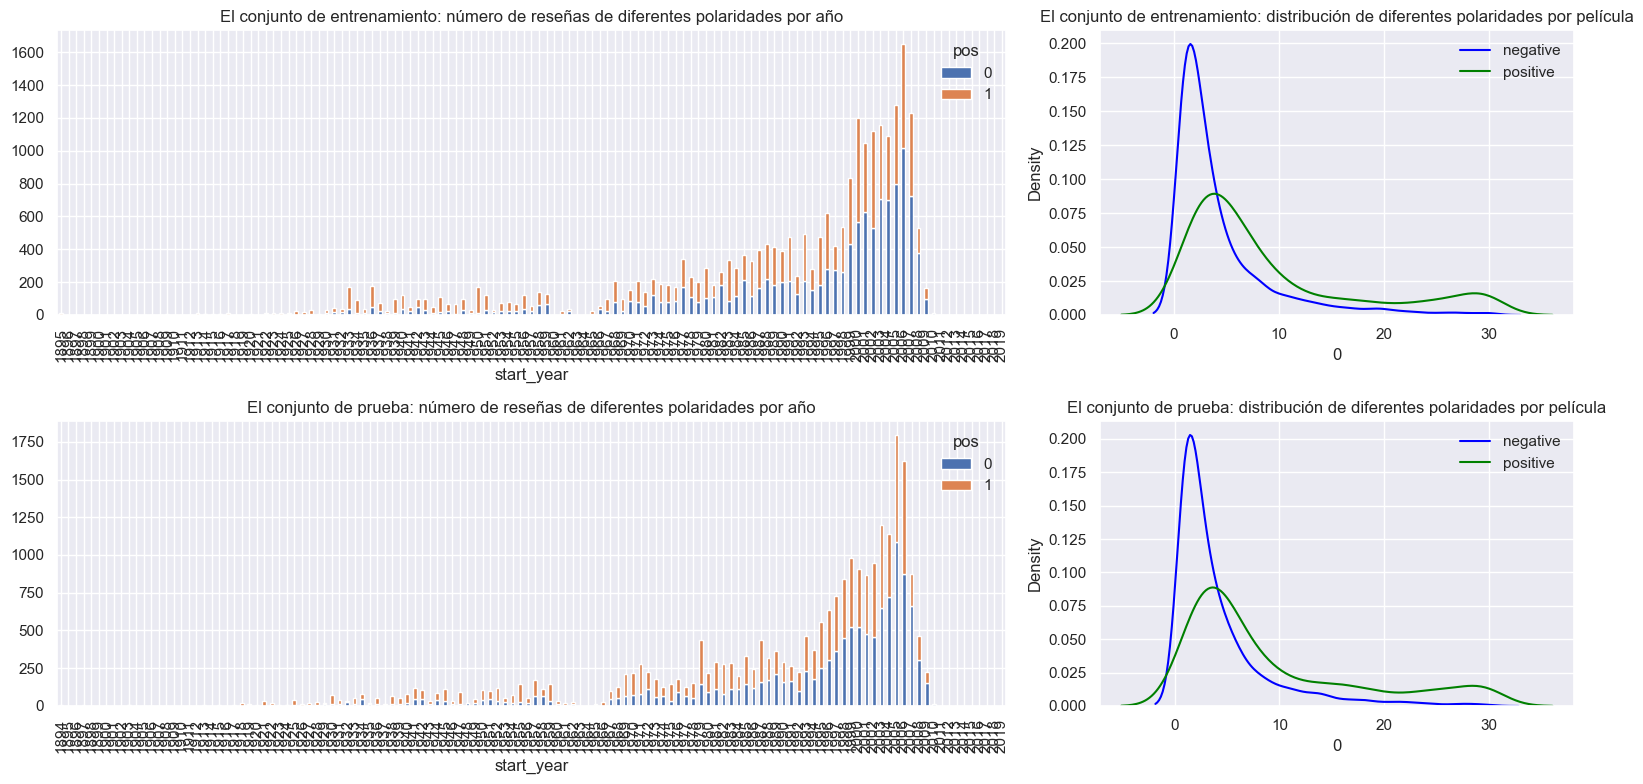

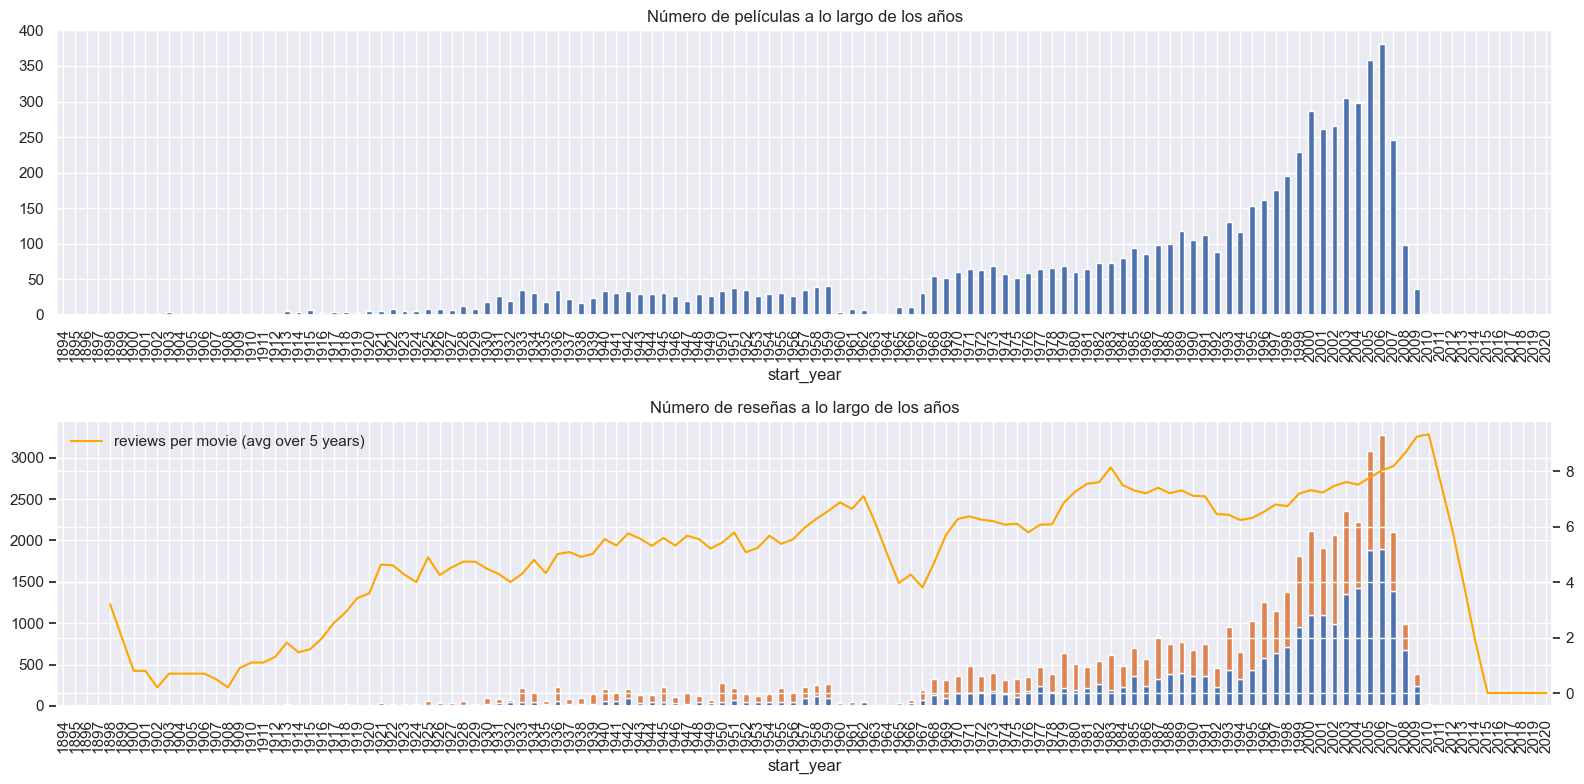

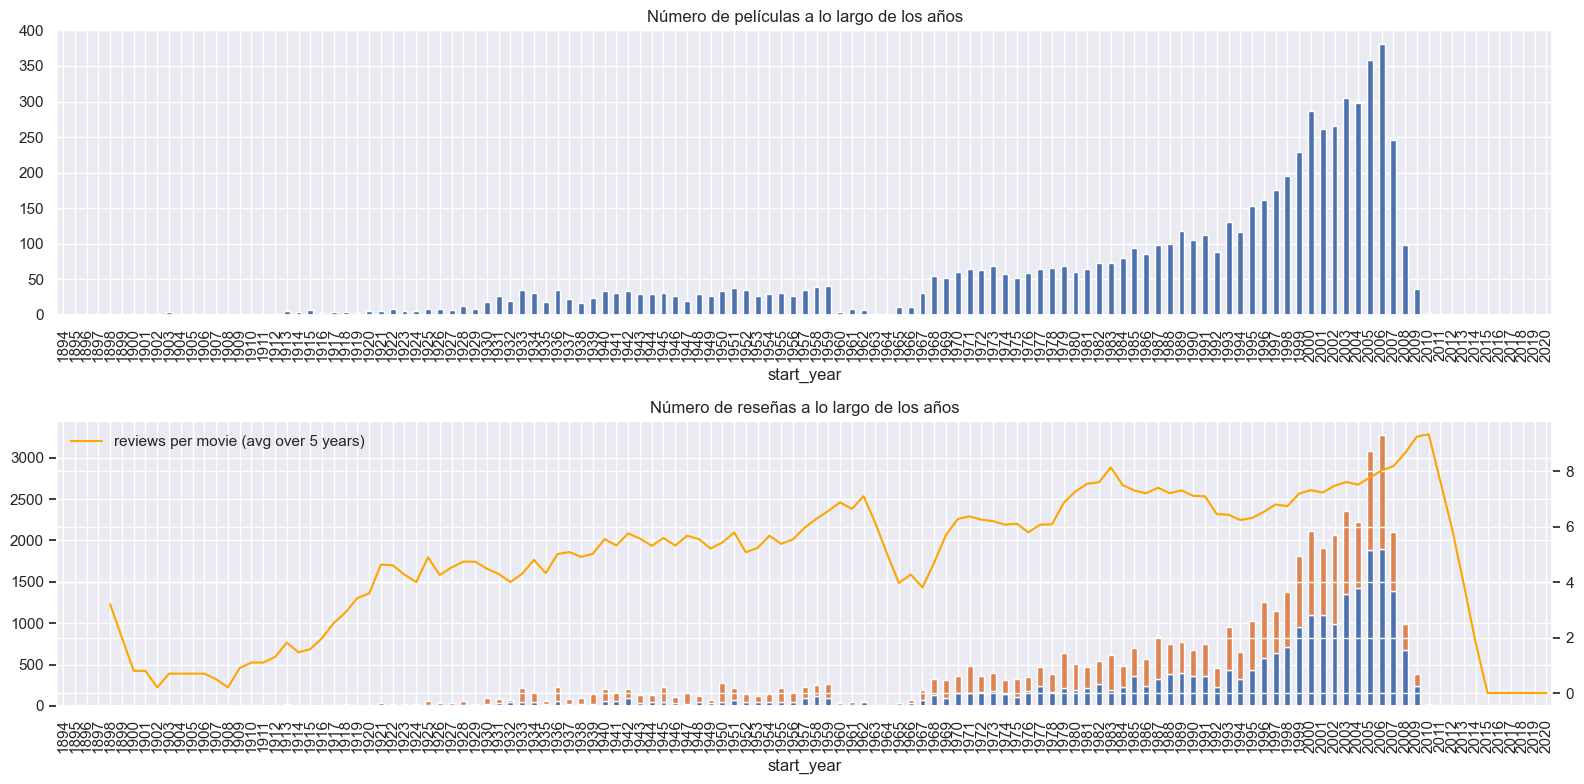

In [38]:
fig, axs = plt.subplots(2, 1, figsize=(16, 8))

ax = axs[0]

dft1 = df_reviews[['tconst', 'start_year']].drop_duplicates() \
    ['start_year'].value_counts().sort_index()
dft1 = dft1.reindex(index=np.arange(dft1.index.min(), max(dft1.index.max(), 2021))).fillna(0)
dft1.plot(kind='bar', ax=ax)
ax.set_title('Número de películas a lo largo de los años')

ax = axs[1]

dft2 = df_reviews.groupby(['start_year', 'pos'])['pos'].count().unstack()
dft2 = dft2.reindex(index=np.arange(dft2.index.min(), max(dft2.index.max(), 2021))).fillna(0)

dft2.plot(kind='bar', stacked=True, label='#reviews (neg, pos)', ax=ax)

dft2 = df_reviews['start_year'].value_counts().sort_index()
dft2 = dft2.reindex(index=np.arange(dft2.index.min(), max(dft2.index.max(), 2021))).fillna(0)
dft3 = (dft2/dft1).fillna(0)
axt = ax.twinx()
dft3.reset_index(drop=True).rolling(5).mean().plot(color='orange', label='reviews per movie (avg over 5 years)', ax=axt)

lines, labels = axt.get_legend_handles_labels()
ax.legend(lines, labels, loc='upper left')

ax.set_title('Número de reseñas a lo largo de los años')

fig.tight_layout()
plt.show()


El número de películas se ve influenciado por factores económicos y sociales. Guerras, recesiones y cambios de hábitos de consumo influyen en la producción. 
Hasta el 2006 se vive el auge del DVD y cine en salar, luego se migra hacia el contenido digital y plataformas online, lo que reduce la cantidad de películas estrenadas en formato tradicional.

Veamos la distribución del número de reseñas por película con el conteo exacto y KDE (solo para saber cómo puede diferir del conteo exacto)

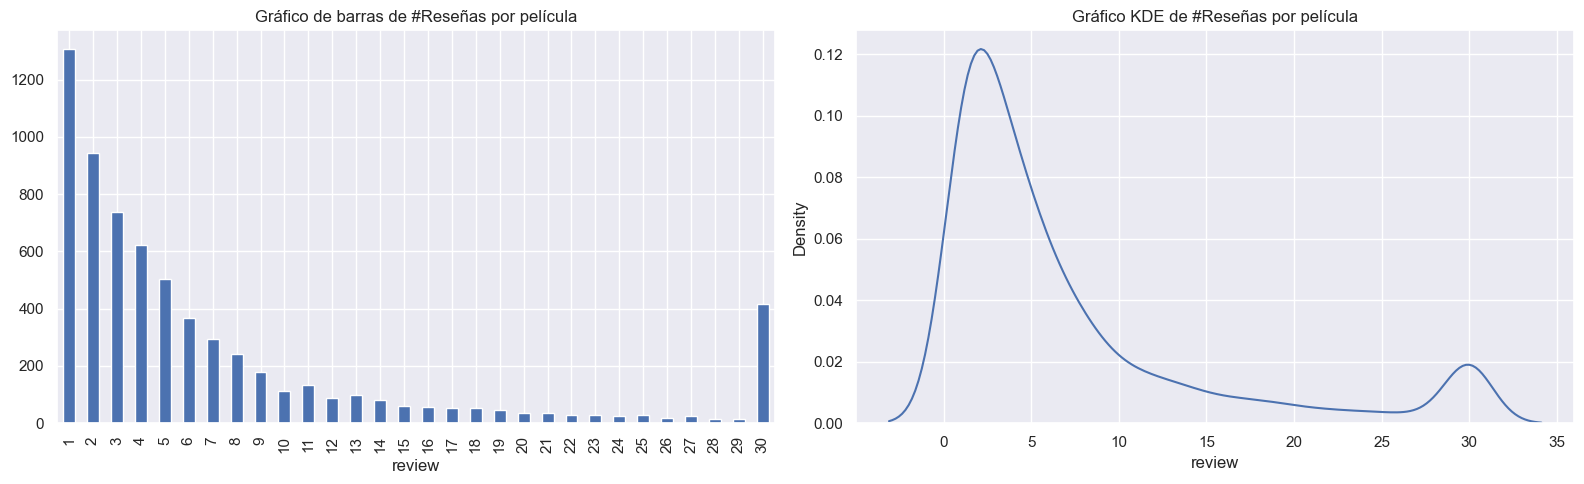

In [39]:

fig, axs = plt.subplots(1, 2, figsize=(16, 5))

ax = axs[0]
dft = df_reviews.groupby('tconst')['review'].count() \
    .value_counts() \
    .sort_index()
dft.plot.bar(ax=ax)
ax.set_title('Gráfico de barras de #Reseñas por película')

ax = axs[1]
dft = df_reviews.groupby('tconst')['review'].count()
sns.kdeplot(dft, ax=ax)
ax.set_title('Gráfico KDE de #Reseñas por película')

fig.tight_layout()
plt.show()



Se observa que la mayoría de las películas tienen pocas reseñas. Y la colita a la derecha muestras que algunas películas tienen muchas reseñas.

Número de reseñas por puntuación

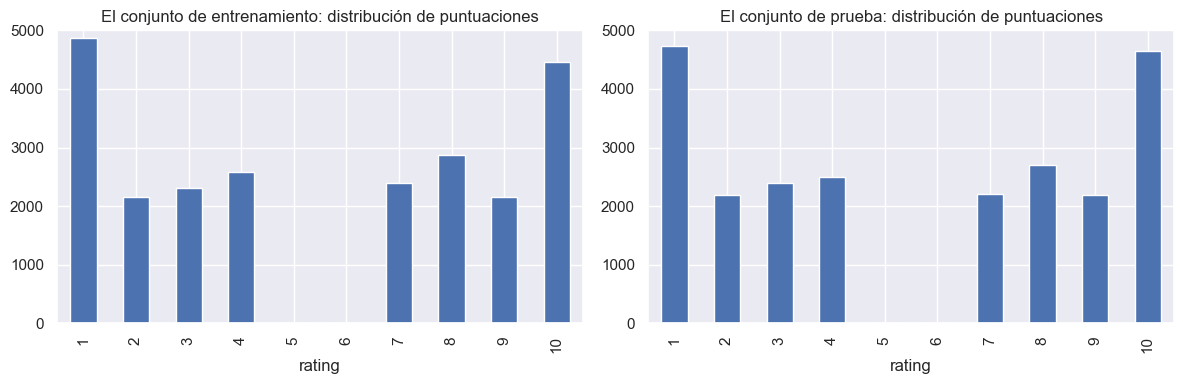

In [40]:

fig, axs = plt.subplots(1, 2, figsize=(12, 4))

ax = axs[0]
dft = df_reviews.query('ds_part == "train"')['rating'].value_counts().sort_index()
dft = dft.reindex(index=np.arange(min(dft.index.min(), 1), max(dft.index.max(), 11))).fillna(0)
dft.plot.bar(ax=ax)
ax.set_ylim([0, 5000])
ax.set_title('El conjunto de entrenamiento: distribución de puntuaciones')

ax = axs[1]
dft = df_reviews.query('ds_part == "test"')['rating'].value_counts().sort_index()
dft = dft.reindex(index=np.arange(min(dft.index.min(), 1), max(dft.index.max(), 11))).fillna(0)
dft.plot.bar(ax=ax)
ax.set_ylim([0, 5000])
ax.set_title('El conjunto de prueba: distribución de puntuaciones')

fig.tight_layout()
plt.show()



Se observa un sesgo hacia opiniones extremas. Las reseñas con puntuaciones intermedias son escasas.

Distribución de reseñas negativas y positivas a lo largo de los años para dos partes del conjunto de datos

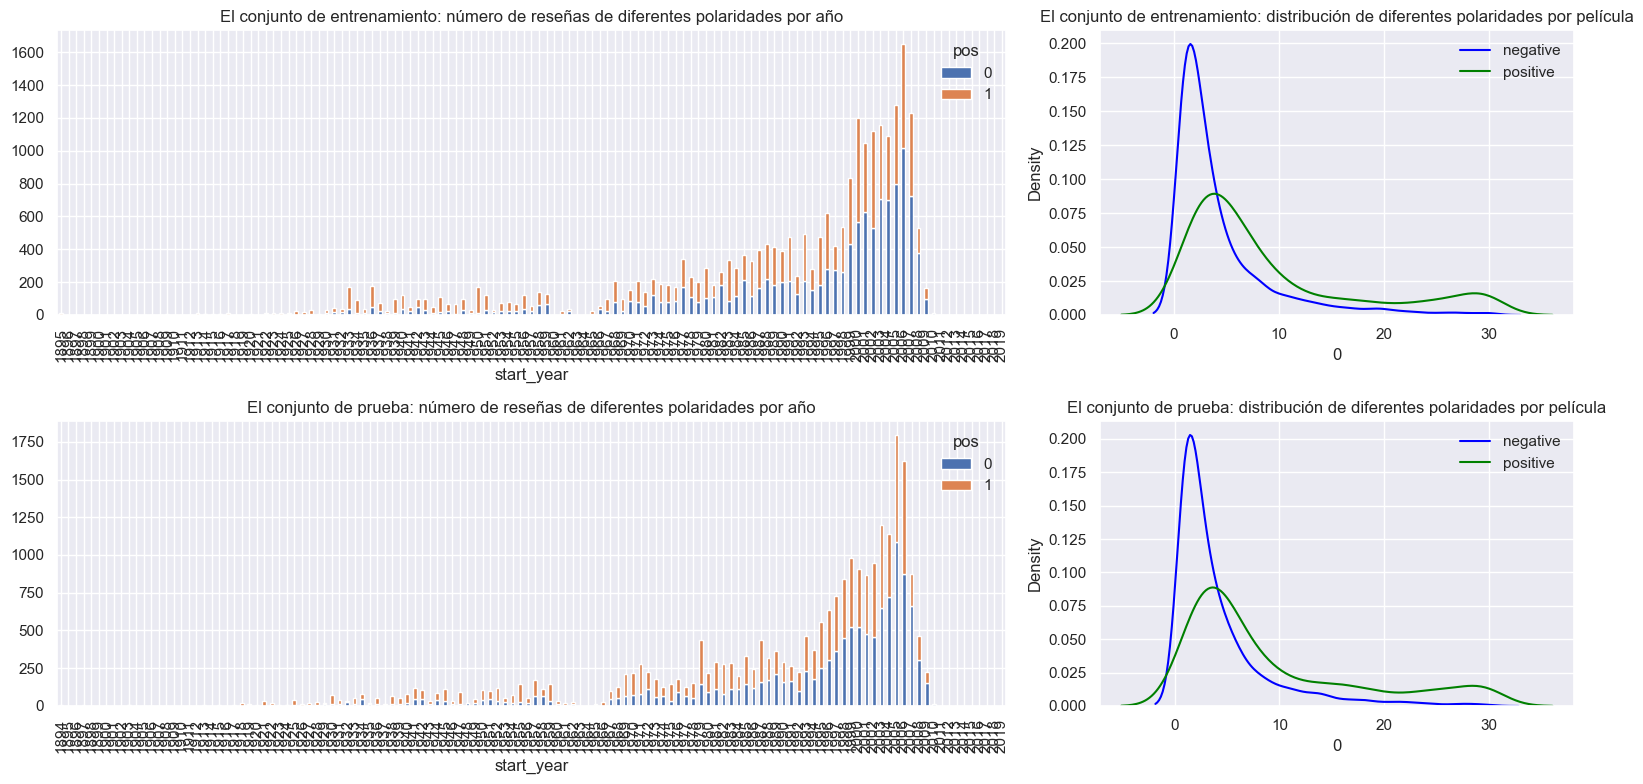

In [41]:
fig, axs = plt.subplots(2, 2, figsize=(16, 8), gridspec_kw=dict(width_ratios=(2, 1), height_ratios=(1, 1)))

ax = axs[0][0]

dft = df_reviews.query('ds_part == "train"').groupby(['start_year', 'pos'])['pos'].count().unstack()
dft.index = dft.index.astype('int')
dft = dft.reindex(index=np.arange(dft.index.min(), max(dft.index.max(), 2020))).fillna(0)
dft.plot(kind='bar', stacked=True, ax=ax)
ax.set_title('El conjunto de entrenamiento: número de reseñas de diferentes polaridades por año')

ax = axs[0][1]

dft = df_reviews.query('ds_part == "train"').groupby(['tconst', 'pos'])['pos'].count().unstack()
sns.kdeplot(dft[0], color='blue', label='negative', ax=ax)
sns.kdeplot(dft[1], color='green', label='positive', ax=ax)
ax.legend()
ax.set_title('El conjunto de entrenamiento: distribución de diferentes polaridades por película')

ax = axs[1][0]

dft = df_reviews.query('ds_part == "test"').groupby(['start_year', 'pos'])['pos'].count().unstack()
dft.index = dft.index.astype('int')
dft = dft.reindex(index=np.arange(dft.index.min(), max(dft.index.max(), 2020))).fillna(0)
dft.plot(kind='bar', stacked=True, ax=ax)
ax.set_title('El conjunto de prueba: número de reseñas de diferentes polaridades por año')

ax = axs[1][1]

dft = df_reviews.query('ds_part == "test"').groupby(['tconst', 'pos'])['pos'].count().unstack()
sns.kdeplot(dft[0], color='blue', label='negative', ax=ax)
sns.kdeplot(dft[1], color='green', label='positive', ax=ax)
ax.legend()
ax.set_title('El conjunto de prueba: distribución de diferentes polaridades por película')

fig.tight_layout()
plt.show()



El número de reseñas aumenta drásticamente a partir de 1990. En la mayoría hay un número similar de reseñas positivas y negativas.

Muchas películas tienen pocas reseñas negativas. Algunas películas reciben más reseñas positivas que negativas. La cola larga del final indica que las películas reciben un número muy alto de reseñas.


OBSERVACIONES DEL EDA
- si una película tiene 50 reseñas positivas y solo 1 negativa, el modelo puede aprender un sesgo hacia esa película. 
- El modelo aprenderá más fácilmente a distinguir reseñas muy positivas vs muy negativas, pero puede confundirse con reseñas “tibias”.

## 4. Preprocesamiento, modelamiento y evaluación

Para realizar el modelo, se construirá la predición de "pos" a partir de "review".

In [34]:
# Librerías
import pandas as pd
import re
from sklearn.feature_extraction.text import TfidfVectorizer

# Función de normalización
def normalize_text(text):
    # Pasar a minúsculas
    text = text.lower()
    # Eliminar caracteres no alfabéticos
    text = re.sub(r'[^a-z\s]', '', text)
    # Quitar espacios múltiples
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Separar train y test
train_df = df_reviews[df_reviews['ds_part'] == 'train']
test_df  = df_reviews[df_reviews['ds_part'] == 'test']

# Normalizar textos
X_train_text = train_df['review'].apply(normalize_text)
y_train = train_df['pos']

X_test_text = test_df['review'].apply(normalize_text)
y_test = test_df['pos']

# Vectorización
vectorizer = TfidfVectorizer(
    max_features=20000,
    stop_words="english",
    ngram_range=(1,2)  # opcional, mejora contexto
)

X_train = vectorizer.fit_transform(X_train_text)
X_test = vectorizer.transform(X_test_text)

# Revisar dimensiones
print("Shape X_train:", X_train.shape)
print("Shape X_test:", X_test.shape)


Shape X_train: (23796, 20000)
Shape X_test: (23533, 20000)


In [42]:
pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   --- ------------------------------------ 8.1/101.7 MB 49.6 MB/s eta 0:00:02
   ------- -------------------------------- 18.9/101.7 MB 49.9 MB/s eta 0:00:02
   ----------- ---------------------------- 30.4/101.7 MB 50.7 MB/s eta 0:00:02
   -------------- ------------------------- 37.2/101.7 MB 46.6 MB/s eta 0:00:02
   ------------------- -------------------- 48.5/101.7 MB 47.1 MB/s eta 0:00:02
   ---------------------- ----------------- 58.5/101.7 MB 47.0 MB/s eta 0:00:01
   --------------------------- ------------ 69.7/101.7 MB 47.6 MB/s eta 0:00:01
   ------------------------------- -------- 80.7/101.7 MB 48.2 MB/s eta 0:00:01
   ------------------------------------ --- 91.8/101.7 MB 48.7 MB/s eta 0:00:01
   --------------------------------------  101.4/101.7 MB 48.8 MB/s eta 0:00:01
   --------------------------------------- 101.7/101.7 MB 45.6 MB/s eta 0:00:00
Note: you may need to restart the kernel to use up

In [47]:
# 1. Definir modelos
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, f1_score

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,       # número de árboles
        max_depth=20,           # profundidad máxima
        n_jobs=-1,              # usa todos los núcleos disponibles
        random_state=42
    ),
    "XGBoost (subset)": XGBClassifier(eval_metric="logloss")
}

# 2. Entrenar y evaluar
results = {}
for name, model in models.items():
    print(f"\nEntrenando {name}...")
    
    if "XGBoost" in name:
        # Usar solo una muestra para XGBoost (más liviano)
        sample_size_train = 5000
        sample_size_test = 2000
        
        X_train_sub = X_train[:sample_size_train]
        y_train_sub = y_train[:sample_size_train]
        
        X_test_sub = X_test[:sample_size_test]
        y_test_sub = y_test[:sample_size_test]
        
        model.fit(X_train_sub, y_train_sub)
        y_pred = model.predict(X_test_sub)
        
        f1 = f1_score(y_test_sub, y_pred)
        results[name] = f1
        
        print(f"\n{name} - Reporte de clasificación (subset):")
        print(classification_report(y_test_sub, y_pred))
        print(f"F1 Score: {f1:.4f}")
        
    else:
        # Entrenar con todo el dataset
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        
        f1 = f1_score(y_test, y_pred)
        results[name] = f1
        
        print(f"\n{name} - Reporte de clasificación:")
        print(classification_report(y_test, y_pred))
        print(f"F1 Score: {f1:.4f}")

# 3. Resumen de resultados
print("\nResumen F1 por modelo:")
for name, f1 in results.items():
    print(f"{name}: {f1:.4f}")


report = classification_report(y_test_sub, y_pred)
print(report)





Entrenando Logistic Regression...

Logistic Regression - Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.88      0.88      0.88     11803
           1       0.88      0.88      0.88     11730

    accuracy                           0.88     23533
   macro avg       0.88      0.88      0.88     23533
weighted avg       0.88      0.88      0.88     23533

F1 Score: 0.8805

Entrenando Random Forest...

Random Forest - Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.86      0.80      0.83     11803
           1       0.81      0.87      0.84     11730

    accuracy                           0.84     23533
   macro avg       0.84      0.84      0.84     23533
weighted avg       0.84      0.84      0.84     23533

F1 Score: 0.8416

Entrenando XGBoost (subset)...

XGBoost (subset) - Reporte de clasificación (subset):
              precision    recall  f1-score   support

           0  

In [ ]:
#Se escribirán 8 reseñas, para armar un dataset externo, para evaluar el modelo logisticRegression.
import pandas as pd

# Crear reseñas externas (fuera del dataset original)
external_reviews = pd.DataFrame({
    "review": [
        "La película fue increíble, me mantuvo emocionado todo el tiempo.",
        "No me gustó nada, la trama era aburrida y predecible.",
        "Excelente actuación de los protagonistas, muy recomendable.",
        "El sonido estaba mal editado y arruinó la experiencia.",
        "Una historia conmovedora que me hizo reflexionar mucho.",
        "Demasiado larga y sin sentido, me costó terminarla.",
        "Gran dirección y fotografía, visualmente espectacular.",
        "Los personajes eran planos y poco interesantes."
    ],
    "pos": [1, 0, 1, 0, 1, 0, 1, 0]  # 1 = positiva, 0 = negativa
})

print(external_reviews)


                                              review  pos
0  La película fue increíble, me mantuvo emociona...    1
1  No me gustó nada, la trama era aburrida y pred...    0
2  Excelente actuación de los protagonistas, muy ...    1
3  El sonido estaba mal editado y arruinó la expe...    0
4  Una historia conmovedora que me hizo reflexion...    1
5  Demasiado larga y sin sentido, me costó termin...    0
6  Gran dirección y fotografía, visualmente espec...    1
7    Los personajes eran planos y poco interesantes.    0


In [ ]:
# Normalizar
external_text = external_reviews['review'].apply(normalize_text)
external_labels = external_reviews['pos']

# Vectorizar con el vocabulario aprendido
X_external = vectorizer.transform(external_text)

# Evaluar con el modelo de regresión logística
log_reg = models["Logistic Regression"]
y_pred_ext = log_reg.predict(X_external)

from sklearn.metrics import classification_report
print("\nEvaluación en reseñas externas:")
print(classification_report(external_labels, y_pred_ext))


Evaluación en reseñas externas:
              precision    recall  f1-score   support

           0       0.60      0.75      0.67         4
           1       0.67      0.50      0.57         4

    accuracy                           0.62         8
   macro avg       0.63      0.62      0.62         8
weighted avg       0.63      0.62      0.62         8



## Conclusiones

Logistic Regression es el modelo más fuerte para este problema de clasificación de texto con TF-IDF, puesto que supera el 0.85 de F1 y mantiene un equilibrio muy bueno entre precisión y recall, además, es eficiente y rápido de entrenar.

Random Foreest tiene un F1 aceptable pero muestra cierta asimentría. Por otro lado, XGBoost queda rezagado.

Ahora, al evaluar el modelo con otro conjunto, fuera de la muestra, se tiene que el modelo generaliza de forma aceptable en datos externos, pero su rendimiento baja respecto al test interno. Tiende a ser más conservador: reconoce mejor las reseñas negativas que las positivas.

